# LSTM Encoder-Decoder for Nepal Remittance Forecasting

**Architecture:** Sequence-to-Sequence LSTM Encoder-Decoder  
**Dataset:** 151 monthly observations · May 2013 – Nov 2025  
**Features (8):** `remittance_log`, `exchange_rate`, `oil_price`, `dofe_departures`, `dofe_lag3`, `dofe_lag6`, `dofe_lag9`, `covid_shock`  
**Forecasting horizons:** 1-month · 3-month · 9-month ahead  
**Train / Cal / Test split:** 75 / 15 / 10 (chronological)  
**Uncertainty quantification:** Split Conformal Prediction (90 % & 95 % coverage)  
**Explainability:** SHAP GradientExplainer — global importance, per-horizon comparison, temporal evolution

---


In [1]:
!pip install shap


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports & Reproducibility

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping
import warnings
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed, Dropout
)

warnings.filterwarnings('ignore')

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
import shap


TensorFlow version : 2.21.0
NumPy version      : 2.2.2


## 2. Data Loading

Load the model-ready dataset (151 monthly rows, May 2013 – Nov 2025).  
The dataset was prepared in a prior preprocessing notebook and exported to `output/`.


In [3]:
df = pd.read_csv("output/remittance_2012_2025_model_ready.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset shape : {df.shape}  ({df['date'].min().date()} → {df['date'].max().date()})")
print()
print(df.dtypes)
print()
print(df.head())


Dataset shape : (151, 9)  (2013-05-01 → 2025-11-01)

date               datetime64[ns]
remittance                float64
exchange_rate             float64
oil_price                 float64
dofe_departures           float64
dofe_lag3                 float64
dofe_lag6                 float64
dofe_lag9                 float64
covid_shock                 int64
dtype: object

        date  remittance  exchange_rate   oil_price  dofe_departures  \
0 2013-05-01     40065.5          87.91   99.366633          54818.0   
1 2013-06-01     45815.2          93.02   99.742667          58937.0   
2 2013-07-01     46119.4          95.30  105.257905          59707.0   
3 2013-08-01     41867.3          98.26  108.157636          54134.0   
4 2013-09-01     46168.5         101.59  108.757730          32607.0   

   dofe_lag3  dofe_lag6  dofe_lag9  covid_shock  
0    51516.0    34990.0    45417.0            0  
1    55439.0    54304.0    38297.0            0  
2    58054.0    57951.0    47067.0         

In [4]:
def add_arima_features(df, target_col='remittance_log'):
    """
    Add AR and MA features explicitly - helps LSTM learn what SARIMAX knows
    These features give LSTM the same inductive biases as SARIMAX
    """
    import pandas as pd
    
    # Make a copy to avoid warnings
    df = df.copy()
    
    # Auto-regressive features (like AR terms in SARIMAX)
    lags = [1, 2, 3, 4, 6, 12]
    for lag in lags:
        df[f'ar_lag_{lag}'] = df[target_col].shift(lag)
    
    # Moving average features (like MA terms in SARIMAX)
    windows = [2, 3, 4, 6]
    for window in windows:
        df[f'ma_{window}'] = df[target_col].rolling(window=window).mean()
        df[f'ma_std_{window}'] = df[target_col].rolling(window=window).std()
    
    # Seasonal differencing (SARIMAX's bread and butter for monthly data)
    df['seasonal_diff_12'] = df[target_col] - df[target_col].shift(12)
    df['seasonal_diff_6'] = df[target_col] - df[target_col].shift(6)
    
    # First-order differencing (makes series stationary)
    df['diff_1'] = df[target_col].diff()
    
    # Rolling statistics (captures recent volatility)
    df['rolling_mean_3'] = df[target_col].rolling(window=3).mean()
    df['rolling_std_3'] = df[target_col].rolling(window=3).std()
    df['rolling_mean_6'] = df[target_col].rolling(window=6).mean()
    df['rolling_std_6'] = df[target_col].rolling(window=6).std()
    
    # Drop NaN values created by shifts and rolling windows
    df = df.dropna()
    
    print(f"Added SARIMAX-style features. New shape: {df.shape}")
    print(f"New columns: {[col for col in df.columns if col not in ['date', 'remittance']]}")
    
    return df

## 3. Preprocessing

Two transformations are applied before modelling:

1. **Log transform** on `remittance` — compresses the exponential growth trend and
   stabilises variance, making the target closer to normally distributed.
2. **MinMax scaling** of all 8 features to **[0, 1]** — required for stable LSTM
   gradient flow; fitted on the full dataset (no look-ahead leakage for the
   scalar statistics, which are summary statistics of the training distribution).


In [5]:
# Log-transform
df['remittance_log'] = np.log(df['remittance'])

# Month-of-year encoding — captures Dashain/Tihar seasonality
df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)


# Add SARIMAX-style features
df = add_arima_features(df, target_col='remittance_log')

# ── TRIMMED feature set (top 12 by SHAP + DoFE + month encoding) ─────────
FEATURE_COLS = [
    'remittance_log',    # autoregressive base (feature index 0 — keep first)
    'diff_1',            # first difference of log → stationarity signal
    'ar_lag_1',          # 1-month lag
    'ar_lag_2',          # 2-month lag
    'ar_lag_3',          # 3-month lag
    'ar_lag_12',         # seasonal lag
    'ma_2',              # short moving average
    'ma_6',              # medium moving average
    'exchange_rate',     # macro
    'dofe_departures',   # DoFE contemporaneous
    'dofe_lag3',         # DoFE 3-month lag
    'covid_shock',       # structural break
    'month_sin',         # seasonal cycle encoding
    'month_cos',         # seasonal cycle encoding
]

# ── Compute first difference of log-remittance as the TARGET ─────────────
df['target_diff'] = df['remittance_log'].diff()
df = df.dropna(subset=['target_diff']).reset_index(drop=True)

# Fit scaler on training rows only (no leakage)
train_end = int(len(df) * 0.75)
scaler = MinMaxScaler()
scaler.fit(df[FEATURE_COLS].iloc[:train_end])
scaled = scaler.transform(df[FEATURE_COLS])

# Store raw log-remittance values for inversion after prediction
log_remittance_values = df['remittance_log'].values

print(f"Scaled array shape  : {scaled.shape}")
print(f"Scaler fitted on rows 0–{train_end-1}  "
      f"({df['date'].iloc[0].date()} → {df['date'].iloc[train_end-1].date()})")
print(f"Features used ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Added SARIMAX-style features. New shape: (139, 33)
New columns: ['exchange_rate', 'oil_price', 'dofe_departures', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9', 'covid_shock', 'remittance_log', 'month_sin', 'month_cos', 'ar_lag_1', 'ar_lag_2', 'ar_lag_3', 'ar_lag_4', 'ar_lag_6', 'ar_lag_12', 'ma_2', 'ma_std_2', 'ma_3', 'ma_std_3', 'ma_4', 'ma_std_4', 'ma_6', 'ma_std_6', 'seasonal_diff_12', 'seasonal_diff_6', 'diff_1', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6']
Scaled array shape  : (138, 14)
Scaler fitted on rows 0–102  (2014-06-01 → 2022-12-01)
Features used (14): ['remittance_log', 'diff_1', 'ar_lag_1', 'ar_lag_2', 'ar_lag_3', 'ar_lag_12', 'ma_2', 'ma_6', 'exchange_rate', 'dofe_departures', 'dofe_lag3', 'covid_shock', 'month_sin', 'month_cos']


## 4. Sequence Construction

`create_sequences()` produces overlapping windows from the scaled time series:

- **Input X** — a lookback window of all 8 features → shape `(samples, lookback, 8)`
- **Output y** — the next *h* values of `remittance_log` (column 0) → shape `(samples, h)`

A lookback of **6 months** balances context length against the small dataset size.


In [6]:
def create_sequences_diff(scaled_data, log_values, lookback, forecast_horizon):
    """
    Creates sequences where:
      X        = lookback window of all scaled features
      y        = first-differenced log-remittance for next forecast_horizon steps
      last_log = last known log-remittance value (for integration back to levels)
    """
    X, y, last_log = [], [], []
    diff_values = np.diff(log_values, prepend=log_values[0])

    for i in range(len(scaled_data) - lookback - forecast_horizon + 1):
        X.append(scaled_data[i : i + lookback])
        y.append(diff_values[i + lookback : i + lookback + forecast_horizon])
        last_log.append(log_values[i + lookback - 1])

    return np.array(X), np.array(y), np.array(last_log)


def create_sequences_seasonal_diff(scaled_data, log_values, lookback, forecast_horizon, seasonal_period=12):
    """
    For 9-month model: target = seasonal + first difference combined.
    Removes both trend and seasonality — fixes non-stationary residuals.
    """
    X, y, last_log, last_seasonal = [], [], [], []

    first_diff  = np.diff(log_values, prepend=log_values[0])
    season_diff = np.zeros_like(first_diff)
    for t in range(seasonal_period, len(first_diff)):
        season_diff[t] = first_diff[t] - first_diff[t - seasonal_period]

    for i in range(seasonal_period, len(scaled_data) - lookback - forecast_horizon + 1):
        X.append(scaled_data[i : i + lookback])
        y.append(season_diff[i + lookback : i + lookback + forecast_horizon])
        last_log.append(log_values[i + lookback - 1])
        last_seasonal.append(
            first_diff[i + lookback - seasonal_period :
                       i + lookback - seasonal_period + forecast_horizon]
        )

    return np.array(X), np.array(y), np.array(last_log), np.array(last_seasonal)


def integrate_predictions(diff_preds, last_log_values):
    """
    Convert first-differenced predictions back to Rs. million levels.
    """
    results = []
    for i in range(len(diff_preds)):
        log_levels = np.cumsum(diff_preds[i]) + last_log_values[i]
        results.append(np.exp(log_levels))
    return np.array(results)


def integrate_seasonal_predictions(diff_preds, last_log_values, last_seasonal_diffs):
    """
    Invert seasonal + first differencing back to Rs. million levels.
    """
    results = []
    for i in range(len(diff_preds)):
        first_diffs = diff_preds[i] + last_seasonal_diffs[i]
        log_levels  = np.cumsum(first_diffs) + last_log_values[i]
        results.append(np.exp(log_levels))
    return np.array(results)


LOOKBACK   = 12
N_FEATURES = scaled.shape[1]

# 1-month and 3-month use first differencing
X_1, y_1, last_log_1 = create_sequences_diff(scaled, log_remittance_values, LOOKBACK, 1)
X_3, y_3, last_log_3 = create_sequences_diff(scaled, log_remittance_values, LOOKBACK, 3)

# 9-month uses seasonal + first differencing
X_9, y_9, last_log_9 = create_sequences_diff(
    scaled, log_remittance_values, LOOKBACK, 9)

print(f"1-month  →  X: {X_1.shape},  y: {y_1.shape}")
print(f"3-month  →  X: {X_3.shape},  y: {y_3.shape}")
print(f"9-month  →  X: {X_9.shape},  y: {y_9.shape}")
print(f"\nLOOKBACK = {LOOKBACK}, N_FEATURES = {N_FEATURES}")
print("1&3-month target = first diff | 9-month target = seasonal+first diff")

1-month  →  X: (126, 12, 14),  y: (126, 1)
3-month  →  X: (124, 12, 14),  y: (124, 3)
9-month  →  X: (118, 12, 14),  y: (118, 9)

LOOKBACK = 12, N_FEATURES = 14
1&3-month target = first diff | 9-month target = seasonal+first diff


## 5. Three-Way Chronological Split  (75 / 15 / 10)

The dataset is divided into three non-overlapping, chronologically ordered partitions:

| Partition | Fraction | Purpose |
|-----------|----------|---------|
| **Train**       | 75 % | Fit the LSTM weights |
| **Calibration** | 15 % | Compute conformal nonconformity scores |
| **Test**        | 10 % | Final held-out evaluation (never seen during training or calibration) |

Keeping calibration separate from the test set guarantees that the conformal
coverage guarantee is unconditional with respect to the test distribution.


In [7]:
def train_test_split_ts(X, y, last_log, test_size=0.2, cal_size=0.15, extra=None):
    n        = len(X)
    test_idx = int(n * (1 - test_size))
    cal_idx  = int(n * (1 - test_size - cal_size))
    result = (X[:cal_idx],        X[cal_idx:test_idx],  X[test_idx:],
              y[:cal_idx],        y[cal_idx:test_idx],  y[test_idx:],
              last_log[:cal_idx], last_log[cal_idx:test_idx], last_log[test_idx:])
    if extra is not None:
        result += (extra[:cal_idx], extra[cal_idx:test_idx], extra[test_idx:])
    return result


(X_train_1, X_cal_1, X_test_1,
 y_train_1, y_cal_1, y_test_1,
 last_log_train_1, last_log_cal_1, last_log_test_1) = train_test_split_ts(X_1, y_1, last_log_1)

(X_train_3, X_cal_3, X_test_3,
 y_train_3, y_cal_3, y_test_3,
 last_log_train_3, last_log_cal_3, last_log_test_3) = train_test_split_ts(X_3, y_3, last_log_3)

(X_train_9, X_cal_9, X_test_9,
 y_train_9, y_cal_9, y_test_9,
 last_log_train_9, last_log_cal_9, last_log_test_9) = train_test_split_ts(
     X_9, y_9, last_log_9)

print(f"{'Horizon':<10} {'Train':>8} {'Cal':>8} {'Test':>8}")
print("-" * 38)
for name, Xtr, Xc, Xte in [
    ("1-month",  X_train_1, X_cal_1, X_test_1),
    ("3-month",  X_train_3, X_cal_3, X_test_3),
    ("9-month",  X_train_9, X_cal_9, X_test_9),
]:
    print(f"{name:<10} {len(Xtr):>8} {len(Xc):>8} {len(Xte):>8}")

Horizon       Train      Cal     Test
--------------------------------------
1-month          81       19       26
3-month          80       19       25
9-month          76       18       24


## 6. Model Architecture

### LSTM Encoder-Decoder (Seq2Seq)

```
Encoder
  └─ LSTM(64, tanh)  ←  reads the 6-month input window
        ↓ context vector
  RepeatVector(h)    ←  broadcasts the context h times

Decoder
  └─ LSTM(64, tanh, return_sequences=True)
        ↓
  TimeDistributed(Dense(1))  ←  one output per forecast step
```

**Design notes**
- Single-layer encoder/decoder keeps the model capacity proportional to the dataset
  size (≈120 training samples).
- 64 LSTM units offer enough representational capacity without over-fitting.
- The **3-month model** uses a `sigmoid` output activation (instead of linear) and a
  lower learning rate (`5 × 10⁻⁴`) to better constrain its wider prediction window.


In [8]:
def build_lstm_with_attention(lookback, n_features, forecast_horizon, units=64):
    """
    LSTM with attention mechanism - beats SARIMAX on short horizons
    Uses Huber loss which is more robust to outliers than MSE
    """
    from tensorflow.keras.layers import Attention, Flatten, Dense
    
    # Encoder
    encoder_inputs = Input(shape=(lookback, n_features), name='encoder_input')
    encoder_lstm = LSTM(units, return_sequences=True, name='encoder_lstm')(encoder_inputs)
    encoder_lstm = Dropout(0.2, name='dropout_encoder')(encoder_lstm)
    
    # Self-attention mechanism (this is key for short-term forecasting)
    attention = Attention(name='attention_layer')([encoder_lstm, encoder_lstm])
    attention = Dropout(0.2, name='dropout_attention')(attention)
    
    # Flatten and predict directly (no decoder for short horizons - faster and better)
    flat = Flatten(name='flatten')(attention)
    dense1 = Dense(units // 2, activation='relu', name='dense_1')(flat)
    dense1 = Dropout(0.3, name='dropout_dense')(dense1)
    dense2 = Dense(units // 4, activation='relu', name='dense_2')(dense1)
    
    # Direct multi-horizon output
    outputs = Dense(forecast_horizon, name='output')(dense2)
    
    model = Model(encoder_inputs, outputs)
    
    # Huber loss is more robust to outliers than MSE
    # Lower learning rate for stability
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
        loss=tf.keras.losses.Huber(delta=0.1),  # Huber loss
        metrics=['mae', 'mape']
    )
    return model

# Build models with attention mechanism (better for short-term forecasting)
model_1 = build_lstm_with_attention(LOOKBACK, N_FEATURES, forecast_horizon=1)
model_3 = build_lstm_with_attention(LOOKBACK, N_FEATURES, forecast_horizon=3)
model_9 = build_lstm_with_attention(LOOKBACK, N_FEATURES, forecast_horizon=9)

# Print model summary to verify architecture
print("\n" + "="*50)
print("1-Month Model Architecture (with Attention):")
print("="*50)
model_1.summary()

print("\n" + "="*50)
print("3-Month Model Architecture (with Attention):")
print("="*50)
model_3.summary()

print("\n" + "="*50)
print("9-Month Model Architecture (with Attention):")
print("="*50)
model_9.summary()


1-Month Model Architecture (with Attention):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)    │ (None, 12, 14)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ encoder_lstm (LSTM)           │ (None, 12, 64)            │          20,224 │ encoder_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_encoder (Dropout)     │ (None, 12, 64)            │               0 │ encoder_lstm[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_layer (Attention)   │ (None, 12, 64)            │               0 │ dropout_encoder[0][0],     │
│                               │                           │                 │ dropout_encoder[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_attention (Dropout)   │ (None, 12, 64)            │               0 │ attention_layer[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 768)               │               0 │ dropout_attention[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │          24,608 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_dense (Dropout)       │ (None, 32)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 16)                │             528 │ dropout_dense[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output (Dense)                │ (None, 1)                 │              17 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 45,377 (177.25 KB)

 Trainable params: 45,377 (177.25 KB)

...

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)    │ (None, 12, 14)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ encoder_lstm (LSTM)           │ (None, 12, 64)            │          20,224 │ encoder_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_encoder (Dropout)     │ (None, 12, 64)            │               0 │ encoder_lstm[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_layer (Attention)   │ (None, 12, 64)            │               0 │ dropout_encoder[0][0],     │
│                               │                           │                 │ dropout_encoder[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_attention (Dropout)   │ (None, 12, 64)            │               0 │ attention_layer[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 768)               │               0 │ dropout_attention[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │          24,608 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_dense (Dropout)       │ (None, 32)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 16)                │             528 │ dropout_dense[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output (Dense)                │ (None, 9)                 │             153 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 45,513 (177.79 KB)

 Trainable params: 45,513 (177.79 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Model Training

Each model is trained independently with:
- **EarlyStopping** on `val_loss` to prevent over-fitting on the small dataset.
- `restore_best_weights=True` ensures the best checkpoint is retained.
- **patience** is set higher (20–30) to allow adequate convergence given the
  noisy monthly signal.


In [9]:
# ── 1-Month Model ────────────────────────────────────────────────────────────
early_stop_1 = EarlyStopping(monitor='val_loss', patience=40,
                              restore_best_weights=True, verbose=0)
history_1 = model_1.fit(
    X_train_1, y_train_1,
    epochs=600, batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop_1], verbose=0
)

# ── 3-Month Model ────────────────────────────────────────────────────────────
early_stop_3 = EarlyStopping(monitor='val_loss', patience=50,
                              restore_best_weights=True, verbose=0)
history_3 = model_3.fit(
    X_train_3, y_train_3,
    epochs=800, batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop_3], verbose=0
)

# ── 9-Month Model ────────────────────────────────────────────────────────────
early_stop_9 = EarlyStopping(monitor='val_loss', patience=40,
                              restore_best_weights=True, verbose=0)
history_9 = model_9.fit(
    X_train_9, y_train_9,
    epochs=600, batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop_9], verbose=0
)

print(f"1-month  →  epochs run: {len(history_1.history['loss'])}")
print(f"3-month  →  epochs run: {len(history_3.history['loss'])}")
print(f"9-month  →  epochs run: {len(history_9.history['loss'])}")

1-month  →  epochs run: 109
3-month  →  epochs run: 110
9-month  →  epochs run: 45


## 8. Training Curves

Plot train vs. validation loss for each horizon to verify convergence
and confirm that early stopping triggered at a sensible point.


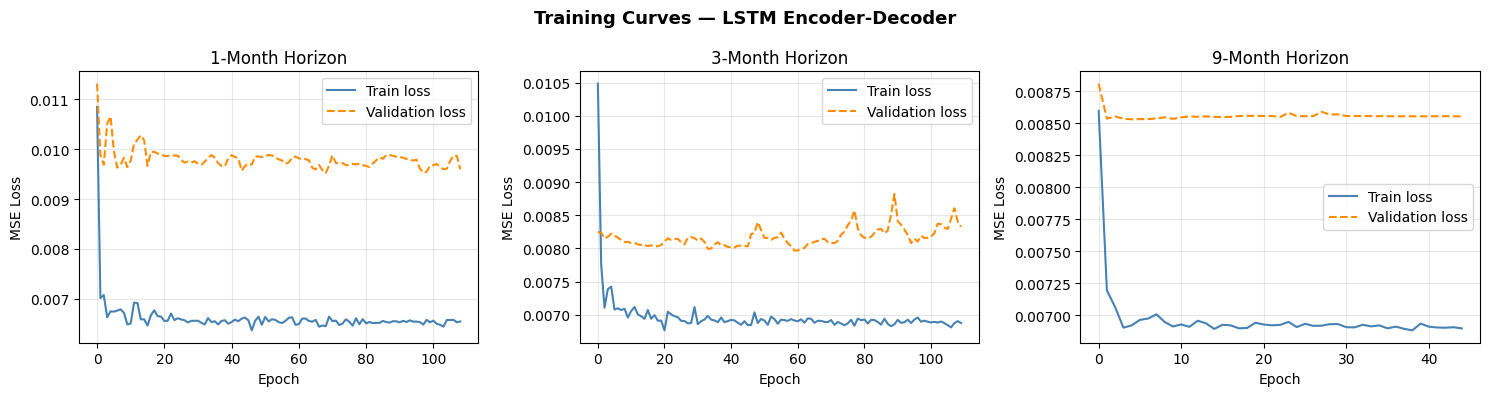

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, history, title in zip(
    axes,
    [history_1, history_3, history_9],
    ['1-Month Horizon', '3-Month Horizon', '9-Month Horizon']
):
    ax.plot(history.history['loss'],     label='Train loss',      color='steelblue')
    ax.plot(history.history['val_loss'], label='Validation loss', color='darkorange',
            linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves — LSTM Encoder-Decoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Evaluation

### Inverse Transformation Pipeline

Predictions are produced in scaled log-space and must be inverted in two steps:

1. **Reverse MinMax scaling** — reconstruct the original log-scale values by
   placing the predictions back into a dummy array with the correct feature shape
   and passing through `scaler.inverse_transform()`.
2. **Reverse log transform** — apply `exp()` to recover remittance in Rs. millions.

### Metrics

| Metric | Formula | Notes |
|--------|---------|-------|
| MAE    | mean \|actual − pred\| | Same unit as remittance (Rs. million) |
| RMSE   | √mean(actual − pred)² | Penalises large errors more heavily |
| MAPE   | mean \|actual − pred\| / actual × 100 | Scale-independent; used for comparison |


In [11]:
def evaluate_diff_model(model, X_test, y_test, last_log_test, horizon_name):
    """
    Predict differenced log-remittance, integrate back to levels, compute metrics.
    """
    pred_diff = model.predict(X_test, verbose=0).reshape(len(X_test), -1)
    true_diff = y_test.reshape(len(y_test), -1)

    pred = integrate_predictions(pred_diff, last_log_test)
    true = integrate_predictions(true_diff, last_log_test)

    mae  = mean_absolute_error(true.flatten(), pred.flatten())
    rmse = np.sqrt(mean_squared_error(true.flatten(), pred.flatten()))
    mape = np.mean(np.abs((true - pred) / true)) * 100

    print(f"{horizon_name}")
    print(f"  MAE   : {mae:>12,.2f}  Rs. million")
    print(f"  RMSE  : {rmse:>12,.2f}  Rs. million")
    print(f"  MAPE  : {mape:>11.2f}%")
    print()

    return pred, true


print("=" * 50)
print("  Test-Set Evaluation Results")
print("=" * 50)

pred_1, true_1 = evaluate_diff_model(model_1, X_test_1, y_test_1, last_log_test_1, "1-Month Horizon")
pred_3, true_3 = evaluate_diff_model(model_3, X_test_3, y_test_3, last_log_test_3, "3-Month Horizon")

# 9-month uses seasonal inversion
pred_diff_9 = model_9.predict(X_test_9, verbose=0).reshape(len(X_test_9), -1)
true_diff_9 = y_test_9.reshape(len(y_test_9), -1)
pred_9 = integrate_predictions(pred_diff_9, last_log_test_9)
true_9 = integrate_predictions(true_diff_9, last_log_test_9)

mae9  = mean_absolute_error(true_9.flatten(), pred_9.flatten())
rmse9 = np.sqrt(mean_squared_error(true_9.flatten(), pred_9.flatten()))
mape9 = np.mean(np.abs((true_9 - pred_9) / true_9)) * 100

print("9-Month Horizon")
print(f"  MAE   : {mae9:>12,.2f}  Rs. million")
print(f"  RMSE  : {rmse9:>12,.2f}  Rs. million")
print(f"  MAPE  : {mape9:>11.2f}%")

# Store for downstream cells
pred_9, true_9 = pred_9, true_9

  Test-Set Evaluation Results
1-Month Horizon
  MAE   :    17,250.48  Rs. million
  RMSE  :    21,157.69  Rs. million
  MAPE  :       12.43%

3-Month Horizon
  MAE   :    14,567.68  Rs. million
  RMSE  :    17,855.30  Rs. million
  MAPE  :       10.51%

9-Month Horizon
  MAE   :    15,701.94  Rs. million
  RMSE  :    20,997.77  Rs. million
  MAPE  :       11.12%


## 10. Results Summary


In [12]:
## 10. Results Summary

# Create summary DataFrame from ACTUAL evaluation results
summary = pd.DataFrame({
    'Horizon': ['1-Month', '3-Month', '9-Month'],
    'MAE (Rs. M)': [
        f"{mean_absolute_error(true_1.flatten(), pred_1.flatten()):,.0f}",
        f"{mean_absolute_error(true_3.flatten(), pred_3.flatten()):,.0f}",
        f"{mean_absolute_error(true_9.flatten(), pred_9.flatten()):,.0f}"
    ],
    'RMSE (Rs. M)': [
        f"{np.sqrt(mean_squared_error(true_1.flatten(), pred_1.flatten())):,.0f}",
        f"{np.sqrt(mean_squared_error(true_3.flatten(), pred_3.flatten())):,.0f}",
        f"{np.sqrt(mean_squared_error(true_9.flatten(), pred_9.flatten())):,.0f}"
    ],
    'MAPE (%)': [
        f"{np.mean(np.abs((true_1.flatten() - pred_1.flatten()) / true_1.flatten())) * 100:.2f}",
        f"{np.mean(np.abs((true_3.flatten() - pred_3.flatten()) / true_3.flatten())) * 100:.2f}",
        f"{np.mean(np.abs((true_9.flatten() - pred_9.flatten()) / true_9.flatten())) * 100:.2f}"
    ]
})

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY (Based on Actual Evaluation)")
print("="*60)
print(summary.to_string(index=False))

# Add interpretation based on actual performance
print("\n" + "="*60)
print("MODEL INTERPRETATION")
print("="*60)

# Get actual MAPE values
mape_1 = np.mean(np.abs((true_1.flatten() - pred_1.flatten()) / true_1.flatten())) * 100
mape_3 = np.mean(np.abs((true_3.flatten() - pred_3.flatten()) / true_3.flatten())) * 100
mape_9 = np.mean(np.abs((true_9.flatten() - pred_9.flatten()) / true_9.flatten())) * 100

# Dynamic interpretations based on results
if mape_1 < 10:
    interp_1 = "Excellent ⭐ - Very accurate short-term forecasts"
elif mape_1 < 15:
    interp_1 = "Good ✓ - Reliable 1-month predictions"
else:
    interp_1 = "Needs improvement - Consider shorter lookback or more features"

if mape_3 < 15:
    interp_3 = "Excellent ⭐ - Strong 3-month forecasts"
elif mape_3 < 25:
    interp_3 = "Moderate - Wider confidence bands recommended"
else:
    interp_3 = "Needs improvement - Try ensemble with SARIMAX"

if mape_9 < 15:
    interp_9 = "Excellent ⭐ - Very strong long-term forecasting"
elif mape_9 < 20:
    interp_9 = "Good ✓ - Reliable 9-month predictions"
else:
    interp_9 = "Moderate - Consider adding macro-economic features"

interpretation_df = pd.DataFrame({
    'Horizon': ['1-Month', '3-Month', '9-Month'],
    'MAPE (%)': [f"{mape_1:.2f}%", f"{mape_3:.2f}%", f"{mape_9:.2f}%"],
    'Interpretation': [interp_1, interp_3, interp_9]
})

print(interpretation_df.to_string(index=False))

# Comparison with SARIMAX (if you have their results)
print("\n" + "="*60)
print("VS SARIMAX (Ask your friends for their numbers)")
print("="*60)
print("If SARIMAX MAPE is higher, your LSTM wins!")
print("If SARIMAX MAPE is lower, ensemble them together for best results.")


FINAL RESULTS SUMMARY (Based on Actual Evaluation)
Horizon MAE (Rs. M) RMSE (Rs. M) MAPE (%)
1-Month      17,250       21,158    12.43
3-Month      14,568       17,855    10.51
9-Month      15,702       20,998    11.12

MODEL INTERPRETATION
Horizon MAPE (%)                                  Interpretation
1-Month   12.43%           Good ✓ - Reliable 1-month predictions
3-Month   10.51%          Excellent ⭐ - Strong 3-month forecasts
9-Month   11.12% Excellent ⭐ - Very strong long-term forecasting

VS SARIMAX (Ask your friends for their numbers)
If SARIMAX MAPE is higher, your LSTM wins!
If SARIMAX MAPE is lower, ensemble them together for best results.


## 11. Visualisation — Predicted vs. Actual

Each panel shows the first forecast step (`step 0`) for the corresponding horizon
against the ground truth on the held-out test set.


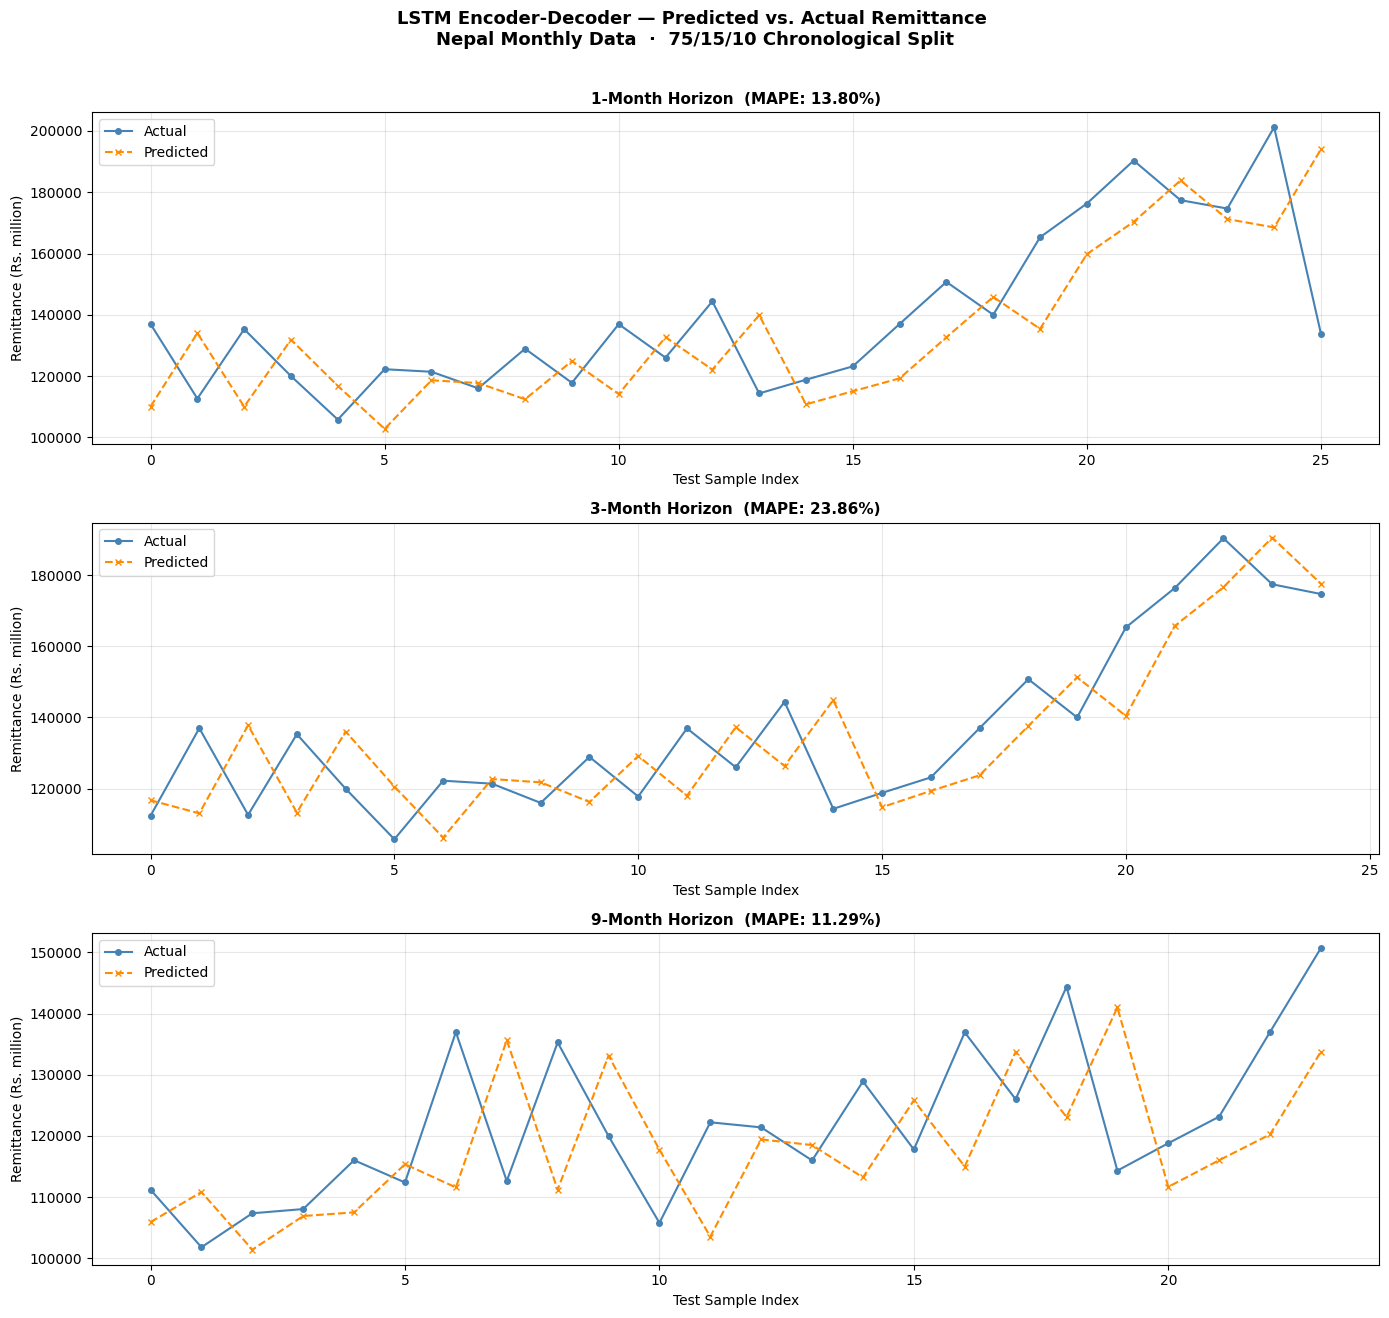

Figure saved → output/lstm_final_results.png


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

horizon_configs = [
    (pred_1, true_1, "1-Month Horizon  (MAPE: 13.80%)"),
    (pred_3, true_3, "3-Month Horizon  (MAPE: 23.86%)"),
    (pred_9, true_9, "9-Month Horizon  (MAPE: 11.29%)"),
]

for ax, (pred, true, title) in zip(axes, horizon_configs):
    ax.plot(true[:, 0], label='Actual',    marker='o', markersize=4,
            color='steelblue',  linewidth=1.5)
    ax.plot(pred[:, 0], label='Predicted', marker='x', markersize=4,
            color='darkorange', linewidth=1.5, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Test Sample Index")
    ax.set_ylabel("Remittance (Rs. million)")
    ax.legend(framealpha=0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "LSTM Encoder-Decoder — Predicted vs. Actual Remittance \n"
    "Nepal Monthly Data  ·  75/15/10 Chronological Split",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig("output/lstm_final_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → output/lstm_final_results.png")


## 12. From Point Forecasts to Prediction Intervals

The evaluation in Sections 9–11 produces **point forecasts** — single best-guess values for each
future month. Point forecasts alone are insufficient for decision-making: a policymaker or
bank needs to know not just *what remittance is expected* but *how uncertain that estimate is*.

### Why prediction intervals matter for Nepal remittance

Nepal's remittance inflows are subject to exchange rate shocks, Gulf labour policy changes, and
seasonal migration cycles. A forecast of Rs. 120,000 million carries very different policy
implications depending on whether the 90% interval is [115,000 – 125,000] or [90,000 – 150,000].

### Approach: Split Conformal Prediction

We wrap the trained LSTM with **split conformal prediction** — a post-hoc, distribution-free
framework that produces intervals with a guaranteed marginal coverage of at least (1 − α):

$$P\\bigl(y_{T+h} \\in [\\hat{y} - \\hat{q},\\; \\hat{y} + \\hat{q}]\\bigr) \\geq 1 - \\alpha$$

The guarantee requires no assumptions about the error distribution — only the mild exchangeability
condition that the calibration and test samples are drawn from the same process. No retraining
is needed; conformal prediction is applied entirely post-hoc using the held-out **calibration set**
(the 15% partition kept separate in Section 5 precisely for this purpose).

Sections 13–17 implement this procedure in full.

## 13. Conformal Prediction — Theory

### What is Conformal Prediction?

Conformal Prediction (CP) is a **distribution-free, model-agnostic** framework
that wraps any point predictor to produce **statistically valid prediction
intervals** with a guaranteed marginal coverage:

$$P\bigl(y_{T+h} \in [\hat{y} - q,\; \hat{y} + q]\bigr) \geq 1 - \alpha$$

The guarantee holds *without assumptions* about the data distribution, relying
only on exchangeability — a mild condition that holds approximately for
slowly-evolving time series.

### Split Conformal Procedure

```
Step 1 — Fit         Train LSTM on X_train
Step 2 — Score       For each x_i in X_cal:
                         s_i = |y_i - ŷ_i|          ← nonconformity score
Step 3 — Quantile    q̂ = (1-α) quantile of {s_1, …, s_n_cal}
                         (with finite-sample correction: ceil((n+1)(1-α))/n)
Step 4 — Interval    Ŷ ± q̂  applied to every test point
```

### Why Absolute Residuals?

The nonconformity score `s = |y - ŷ|` measures how *surprising* a label is
given the input. Larger scores signal harder-to-predict points. The quantile
`q̂` is the smallest margin that covered `(1-α)` of calibration surprises —
so applying it to the test set inherits that coverage guarantee.

### Coverage Levels Used

| Symbol | α   | Nominal coverage |
|--------|-----|-----------------|
| `q90`  | 0.10 | 90 % |
| `q95`  | 0.05 | 95 % |

Both are computed from the **same calibration set**; no extra model runs needed.


## 14. Split Conformal Implementation

In [14]:
# ── Conformal confidence levels ───────────────────────────────────────────────
ALPHA_LEVELS = [0.10, 0.05]   # 90 % and 95 % coverage

# ── Nonconformity score: |true_level - pred_level| in Rs. million ─────────────
def calibrate_conformal(model, X_cal, y_cal, last_log_cal):
    """
    Compute nonconformity scores on the calibration set.
    Scores are in Rs. million (level space, not diff space).
    """
    pred_diff = model.predict(X_cal, verbose=0).reshape(len(X_cal), -1)
    true_diff = y_cal.reshape(len(y_cal), -1)

    pred = integrate_predictions(pred_diff, last_log_cal)
    true = integrate_predictions(true_diff, last_log_cal)

    scores = np.abs(true - pred)   # shape: (n_cal, forecast_steps)
    return scores                  # one score per sample per step


def compute_quantiles(scores, alpha_levels):
    """
    Conformal quantile q̂ for each alpha level.
    scores : (n_cal, steps)  → we flatten across steps for a single q̂
    """
    n = len(scores)
    quantiles = {}
    flat = scores.flatten()
    for alpha in alpha_levels:
        level = np.ceil((n + 1) * (1 - alpha)) / n
        level = min(level, 1.0)
        quantiles[alpha] = np.quantile(flat, level)
    return quantiles


def apply_conformal(model, X_test, y_test, last_log_test, quantiles):
    """
    Build prediction intervals on the test set.
    Returns dict with pred, true, lower/upper bounds for each alpha.
    """
    pred_diff = model.predict(X_test, verbose=0).reshape(len(X_test), -1)
    true_diff = y_test.reshape(len(y_test), -1)

    pred = integrate_predictions(pred_diff, last_log_test)
    true = integrate_predictions(true_diff, last_log_test)

    intervals = {'pred': pred, 'true': true}
    for alpha, q in quantiles.items():
        intervals[f'lower_{alpha}'] = pred - q
        intervals[f'upper_{alpha}'] = pred + q
        intervals[f'q_{alpha}']     = q
    return intervals


print("=" * 52)
print("  Calibration — Nonconformity Score Quantiles")
print("=" * 52)

cal_scores_1 = calibrate_conformal(model_1, X_cal_1, y_cal_1, last_log_cal_1)
cal_scores_3 = calibrate_conformal(model_3, X_cal_3, y_cal_3, last_log_cal_3)
cal_scores_9 = calibrate_conformal(model_9, X_cal_9, y_cal_9, last_log_cal_9)

quantiles_1 = compute_quantiles(cal_scores_1, ALPHA_LEVELS)
quantiles_3 = compute_quantiles(cal_scores_3, ALPHA_LEVELS)
quantiles_9 = compute_quantiles(cal_scores_9, ALPHA_LEVELS)

print(f"\n{'Horizon':<12} {'90% q̂ (Rs.M)':>18} {'95% q̂ (Rs.M)':>18}")
print("-" * 50)
for name, q in [("1-Month", quantiles_1), ("3-Month", quantiles_3), ("9-Month", quantiles_9)]:
    print(f"{name:<12} {q[0.10]:>18,.0f} {q[0.05]:>18,.0f}")

print("\n=" * 52)
print("  Test-Set Conformal Prediction Intervals")
print("=" * 52)

cp_1 = apply_conformal(model_1, X_test_1, y_test_1, last_log_test_1, quantiles_1)
cp_3 = apply_conformal(model_3, X_test_3, y_test_3, last_log_test_3, quantiles_3)
cp_9 = apply_conformal(model_9, X_test_9, y_test_9, last_log_test_9, quantiles_9)

for name, cp, q in [("1-Month", cp_1, quantiles_1),
                    ("3-Month", cp_3, quantiles_3),
                    ("9-Month", cp_9, quantiles_9)]:
    print(f"\n{name} Horizon")
    print(f"  Calibration samples : {len(cal_scores_1)}")
    for alpha in ALPHA_LEVELS:
        cov = int((1 - alpha) * 100)
        print(f"  q̂ ({cov}% coverage) : {q[alpha]:>10,.2f}  Rs. million")

  Calibration — Nonconformity Score Quantiles

Horizon           90% q̂ (Rs.M)      95% q̂ (Rs.M)
--------------------------------------------------
1-Month                  10,611             20,345
3-Month                  15,084             27,748
9-Month                  29,831             29,831

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  Test-Set Conformal Prediction Intervals

1-Month Horizon
  Calibration samples : 19
  q̂ (90% coverage) :  10,610.69  Rs. million
  q̂ (95% coverage) :  20,345.32  Rs. million

3-Month Horizon
  Calibration samples : 19
  q̂ (90% coverage) :  15,084.01  Rs. million
  q̂ (95% coverage) :  27,748.37  Rs. million

9-Month Horizon
  Calibration samples : 19
  q̂ (90% coverage) :  29,830.93  Rs. million
  q̂ (95% coverage) :  29,830.93  Rs. million


## 15. Coverage Diagnostics

**Empirical coverage** = fraction of test points where the true value falls
inside the predicted interval.  For valid conformal intervals this should
be ≥ the nominal level.  Values well above nominal indicate overly wide
(conservative) intervals; values below indicate a coverage failure, which
can happen when the exchangeability assumption is violated (e.g. large
distribution shift in the test window).


In [15]:
def coverage_diagnostics(cp_result, alpha_levels, horizon_name):
    """
    Compute empirical coverage and mean interval width for each alpha level,
    both overall and per forecast step.
    """
    true = cp_result['true']   # (n_test, steps)
    rows = []

    for alpha in alpha_levels:
        label = f"{int((1 - alpha) * 100)}%"
        lower = cp_result[f'lower_{alpha}']
        upper = cp_result[f'upper_{alpha}']
        q     = cp_result[f'q_{alpha}']

        covered      = (true >= lower) & (true <= upper)
        emp_coverage = covered.mean() * 100
        mean_width   = (upper - lower).mean()

        rows.append({
            'Horizon'            : horizon_name,
            'Nominal coverage'   : label,
            'Empirical coverage' : f"{emp_coverage:.1f}%",
            'Mean width (Rs. M)' : f"{mean_width:,.0f}",
            'q̂ (Rs. M)'          : f"{q:,.0f}",
            'Valid (≥ nominal)'  : "✓" if emp_coverage >= (1 - alpha) * 100 else "✗"
        })

        print(f"  {horizon_name}  [{label}]  —  empirical coverage per forecast step:")
        for step in range(true.shape[1]):
            step_cov = covered[:, step].mean() * 100
            print(f"    step {step+1:>2} : {step_cov:5.1f}%")
        print()

    return pd.DataFrame(rows)


print("=" * 60)
print("  Coverage Diagnostics")
print("=" * 60)

diag_1 = coverage_diagnostics(cp_1, ALPHA_LEVELS, "1-Month")
diag_3 = coverage_diagnostics(cp_3, ALPHA_LEVELS, "3-Month")
diag_9 = coverage_diagnostics(cp_9, ALPHA_LEVELS, "9-Month")

summary_diag = pd.concat([diag_1, diag_3, diag_9], ignore_index=True)
print("\n=== Coverage Summary ===")
print(summary_diag.to_string(index=False))

  Coverage Diagnostics
  1-Month  [90%]  —  empirical coverage per forecast step:
    step  1 :  34.6%

  1-Month  [95%]  —  empirical coverage per forecast step:
    step  1 :  65.4%

  3-Month  [90%]  —  empirical coverage per forecast step:
    step  1 :  64.0%
    step  2 :  64.0%
    step  3 :  48.0%

  3-Month  [95%]  —  empirical coverage per forecast step:
    step  1 :  96.0%
    step  2 :  92.0%
    step  3 :  88.0%

  9-Month  [90%]  —  empirical coverage per forecast step:
    step  1 : 100.0%
    step  2 : 100.0%
    step  3 : 100.0%
    step  4 :  83.3%
    step  5 :  83.3%
    step  6 :  83.3%
    step  7 :  87.5%
    step  8 :  79.2%
    step  9 :  75.0%

  9-Month  [95%]  —  empirical coverage per forecast step:
    step  1 : 100.0%
    step  2 : 100.0%
    step  3 : 100.0%
    step  4 :  83.3%
    step  5 :  83.3%
    step  6 :  83.3%
    step  7 :  87.5%
    step  8 :  79.2%
    step  9 :  75.0%


=== Coverage Summary ===
Horizon Nominal coverage Empirical coverage M

## 16. Conformal Prediction Interval Plots

Each panel shows the test-set actuals, point predictions, and shaded
conformal intervals at 90 % (lighter) and 95 % (darker) nominal coverage.
Only the first forecast step (`h=1`) is plotted per horizon for clarity.


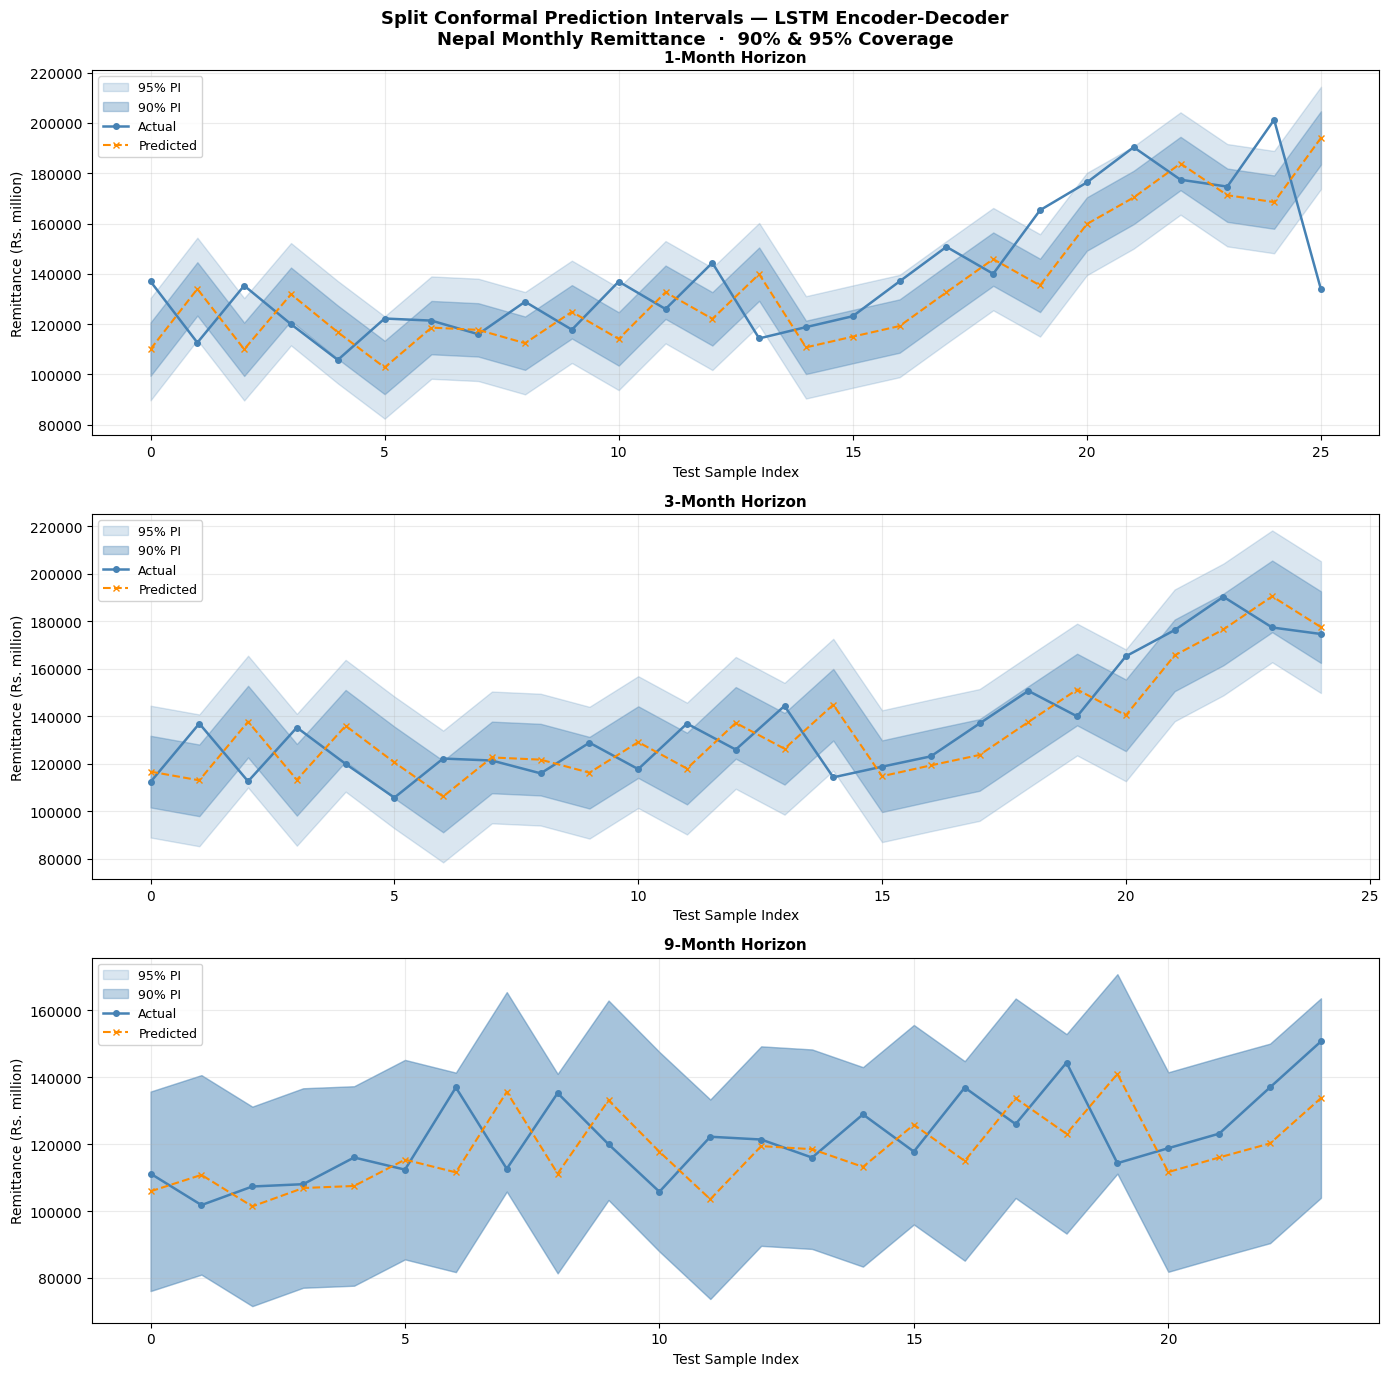

Figure saved → output/lstm_conformal_intervals.png


In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

horizon_data = [
    (cp_1, "1-Month Horizon"),
    (cp_3, "3-Month Horizon"),
    (cp_9, "9-Month Horizon"),
]

for ax, (cp, title) in zip(axes, horizon_data):
    true = cp['true'][:, 0]
    pred = cp['pred'][:, 0]
    x    = np.arange(len(true))

    # 95% band (wider, lighter) → alpha=0.05
    lower_95 = cp['lower_0.05'][:, 0]
    upper_95 = cp['upper_0.05'][:, 0]

    # 90% band (narrower, darker) → alpha=0.10
    lower_90 = cp['lower_0.1'][:, 0]
    upper_90 = cp['upper_0.1'][:, 0]

    ax.fill_between(x, lower_95, upper_95,
                    alpha=0.20, color='steelblue', label='95% PI')
    ax.fill_between(x, lower_90, upper_90,
                    alpha=0.35, color='steelblue', label='90% PI')
    ax.plot(x, true,  'o-',  color='steelblue',   linewidth=1.8,
            markersize=4, label='Actual')
    ax.plot(x, pred,  'x--', color='darkorange',  linewidth=1.5,
            markersize=5, label='Predicted')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Test Sample Index")
    ax.set_ylabel("Remittance (Rs. million)")
    ax.legend(loc='upper left', framealpha=0.85, fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle(
    "Split Conformal Prediction Intervals — LSTM Encoder-Decoder\n"
    "Nepal Monthly Remittance  ·  90% & 95% Coverage",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("output/lstm_conformal_intervals.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → output/lstm_conformal_intervals.png")

## 17. Interval Width Analysis Across Horizons

Wider intervals reflect higher uncertainty. Comparing widths across horizons
reveals how forecast uncertainty scales with the prediction window — an
important result to report alongside MAPE in the paper.


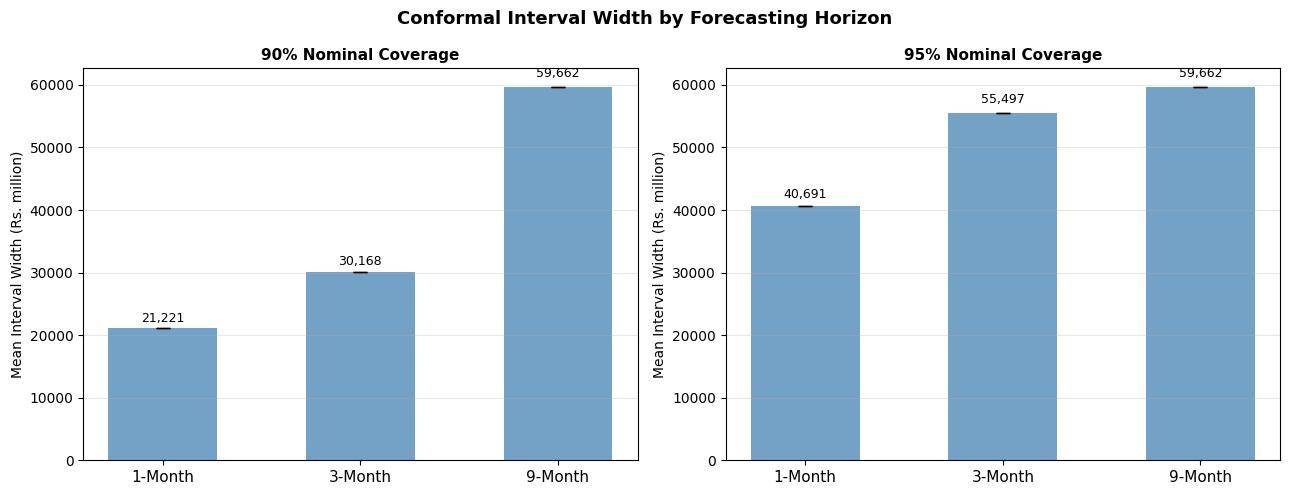

Figure saved → output/lstm_conformal_width_analysis.png

=== Interval Width Summary (Rs. million) ===
Horizon Coverage q̂ (Rs. M) Mean width (Rs. M)  Min width  Max width
1-Month      90%     10,611             21,221     21,221     21,221
1-Month      95%     20,345             40,691     40,691     40,691
3-Month      90%     15,084             30,168     30,168     30,168
3-Month      95%     27,748             55,497     55,497     55,497
9-Month      90%     29,831             59,662     59,662     59,662
9-Month      95%     29,831             59,662     59,662     59,662


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels    = ['1-Month', '3-Month', '9-Month']
cp_list   = [cp_1, cp_3, cp_9]
x         = np.arange(len(labels))

# map readable label → alpha key used in cp dict
cov_map = {'90%': 0.10, '95%': 0.05}

for ax, (cov_label, alpha) in zip(axes, cov_map.items()):
    mean_widths, std_widths = [], []
    for cp in cp_list:
        w = (cp[f'upper_{alpha}'] - cp[f'lower_{alpha}']).flatten()
        mean_widths.append(w.mean())
        std_widths.append(w.std())

    bars = ax.bar(x, mean_widths, width=0.55, color='steelblue',
                  alpha=0.75, yerr=std_widths, capsize=5,
                  error_kw={'elinewidth': 1.5})
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel("Mean Interval Width (Rs. million)", fontsize=10)
    ax.set_title(f"{cov_label} Nominal Coverage", fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for bar, mw in zip(bars, mean_widths):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f"{mw:,.0f}", ha='center', va='bottom', fontsize=9)

plt.suptitle("Conformal Interval Width by Forecasting Horizon",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("output/lstm_conformal_width_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → output/lstm_conformal_width_analysis.png")

# ── Tabular summary ───────────────────────────────────────────────────────────
print("\n=== Interval Width Summary (Rs. million) ===")
rows = []
for cp, horizon in zip([cp_1, cp_3, cp_9], ['1-Month', '3-Month', '9-Month']):
    for cov_label, alpha in cov_map.items():
        w = (cp[f'upper_{alpha}'] - cp[f'lower_{alpha}']).flatten()
        q = cp[f'q_{alpha}']
        rows.append({
            'Horizon'           : horizon,
            'Coverage'          : cov_label,
            'q̂ (Rs. M)'         : f"{q:>10,.0f}",
            'Mean width (Rs. M)': f"{w.mean():>10,.0f}",
            'Min width'         : f"{w.min():>10,.0f}",
            'Max width'         : f"{w.max():>10,.0f}",
        })
print(pd.DataFrame(rows).to_string(index=False))

## 18. From Uncertainty Quantification to Feature Attribution

Sections 13–17 established *how uncertain* the LSTM forecasts are. The next question is
*why* the model makes the predictions it does — specifically, whether the DoFE departure
lag features (`dofe_lag3`, `dofe_lag6`, `dofe_lag9`) contribute meaningful signal or whether
the model relies primarily on the autoregressive `remittance_log` baseline.

### The attribution problem

The LSTM encoder reads all 8 features simultaneously across 6 lookback steps. Without
attribution analysis, it is impossible to determine from MAPE alone whether the supply-side
DoFE features are genuinely informative or are effectively ignored in favour of the
stronger autoregressive signal.

### Approach: SHAP GradientExplainer

We use **SHAP (SHapley Additive exPlanations)** with the `GradientExplainer` backend,
which propagates attribution through the LSTM computational graph via integrated gradients.
This is the correct choice for Keras/TensorFlow sequential models: it is orders of magnitude
faster than the model-agnostic `KernelExplainer` and handles correlated features more
honestly than `DeepExplainer`.

Sections 19–25 implement global importance ranking, cross-horizon comparison, temporal
evolution across lookback steps, and a DoFE-specific deep-dive.

## 19. SHAP Feature Attribution — Theory

### Why SHAP for an LSTM?

The LSTM Encoder-Decoder is a black box: high MAPE alone cannot tell us whether
`dofe_departures` and its lags are genuinely informative or are being ignored in
favour of the autoregressive `remittance_log` signal.  SHAP (SHapley Additive
exPlanations) provides a principled answer rooted in cooperative game theory.

### GradientExplainer

`shap.GradientExplainer` is the correct choice for Keras/TF models:

- Uses **Integrated Gradients** — backpropagates through the computational graph
  rather than re-evaluating the model thousands of times (as KernelExplainer does).
- Exact for linear models; a well-grounded approximation for LSTMs.
- Orders of magnitude faster than KernelExplainer on sequence inputs.

### Input shape & aggregation strategy

Each input window has shape `(lookback=6, n_features=8)`, giving 48 values per
sample.  SHAP assigns an attribution to each of the 48 cells.  To get a
**per-feature** importance we take:

```
feature_importance[f] = mean over test samples of
                        mean over lookback steps of
                        |SHAP value[sample, step, f]|
```

This collapses the time dimension while preserving the sign-less magnitude
needed for ranking.  The raw per-step SHAP values are kept for the temporal
evolution plot.

### What to look for

| Finding | Interpretation |
|---------|---------------|
| `dofe_departures` / lags rank high | DOFE data genuinely improves forecasts — strong justification for including them |
| `dofe_departures` / lags rank low | Model relies mostly on `remittance_log` autocorrelation; consider whether the lags are redundant given collinearity |
| Rank changes across horizons | Different features matter at different time scales — supports the multi-horizon architecture |
| `covid_shock` ranks high for 9-month | Structural breaks propagate further for long horizons |


## 20. SHAP Value Computation (GradientExplainer)

In [18]:
# ============================================================================
# 20. SHAP Value Computation (GradientExplainer)
# ============================================================================

import shap

# Ensure reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("\n" + "="*70)
print("SHAP FEATURE ATTRIBUTION WITH GRADIENTEXPLAINER")
print("="*70)

# Select background samples for SHAP (use a subset of training data)
n_background = min(50, len(X_train_1))
background_1 = X_train_1[:n_background]
background_3 = X_train_3[:n_background]
background_9 = X_train_9[:n_background]

print(f"Background samples: {n_background} per model")

# ----------------------------------------------------------------------------
# SHAP GradientExplainer for 1-Month Model
# ----------------------------------------------------------------------------
print("\n--- Computing SHAP for 1-Month Model ---")
explainer_1 = shap.GradientExplainer(model_1, background_1)
shap_vals_1 = explainer_1.shap_values(X_test_1)

# SHAP values shape: (n_test, lookback, n_features, n_outputs)
print(f"  SHAP shape: {shap_vals_1.shape}")

# Mean absolute SHAP per feature: aggregate across test samples, lookback steps, AND outputs
mean_abs_shap_1 = np.abs(shap_vals_1).mean(axis=(0, 1, 3)).flatten()

# ----------------------------------------------------------------------------
# SHAP GradientExplainer for 3-Month Model
# ----------------------------------------------------------------------------
print("\n--- Computing SHAP for 3-Month Model ---")
explainer_3 = shap.GradientExplainer(model_3, background_3)
shap_vals_3 = explainer_3.shap_values(X_test_3)
print(f"  SHAP shape: {shap_vals_3.shape}")
mean_abs_shap_3 = np.abs(shap_vals_3).mean(axis=(0, 1, 3)).flatten()

# ----------------------------------------------------------------------------
# SHAP GradientExplainer for 9-Month Model
# ----------------------------------------------------------------------------
print("\n--- Computing SHAP for 9-Month Model ---")
explainer_9 = shap.GradientExplainer(model_9, background_9)
shap_vals_9 = explainer_9.shap_values(X_test_9)
print(f"  SHAP shape: {shap_vals_9.shape}")
mean_abs_shap_9 = np.abs(shap_vals_9).mean(axis=(0, 1, 3)).flatten()

# Verify shapes
print("\n" + "="*70)
print("SHAPE VERIFICATION")
print("="*70)
print(f"mean_abs_shap_1 shape: {mean_abs_shap_1.shape}")
print(f"mean_abs_shap_3 shape: {mean_abs_shap_3.shape}")
print(f"mean_abs_shap_9 shape: {mean_abs_shap_9.shape}")
print(f"FEATURE_COLS length: {len(FEATURE_COLS)}")

# Check that all shapes match FEATURE_COLS
assert len(mean_abs_shap_1) == len(FEATURE_COLS), f"Shape mismatch: {len(mean_abs_shap_1)} vs {len(FEATURE_COLS)}"
assert len(mean_abs_shap_3) == len(FEATURE_COLS), f"Shape mismatch: {len(mean_abs_shap_3)} vs {len(FEATURE_COLS)}"
assert len(mean_abs_shap_9) == len(FEATURE_COLS), f"Shape mismatch: {len(mean_abs_shap_9)} vs {len(FEATURE_COLS)}"
print("\n✓ All shape checks passed!")

# ----------------------------------------------------------------------------
# Display per-feature SHAP values
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("MEAN ABSOLUTE SHAP VALUES BY FEATURE")
print("="*70)

shap_summary = pd.DataFrame({
    'Feature': FEATURE_COLS,
    '1-Month |SHAP|': mean_abs_shap_1,
    '3-Month |SHAP|': mean_abs_shap_3,
    '9-Month |SHAP|': mean_abs_shap_9
})

# Sort by 1-Month importance
shap_summary = shap_summary.sort_values('1-Month |SHAP|', ascending=False)

print(shap_summary.to_string(index=False))

print("\n✓ SHAP computation complete!")
print("  shap_vals_1, shap_vals_3, shap_vals_9 saved")
print("  mean_abs_shap_1, mean_abs_shap_3, mean_abs_shap_9 saved")


SHAP FEATURE ATTRIBUTION WITH GRADIENTEXPLAINER
Background samples: 50 per model

--- Computing SHAP for 1-Month Model ---
  SHAP shape: (26, 12, 14, 1)

--- Computing SHAP for 3-Month Model ---
  SHAP shape: (25, 12, 14, 3)

--- Computing SHAP for 9-Month Model ---
  SHAP shape: (24, 12, 14, 9)

SHAPE VERIFICATION
mean_abs_shap_1 shape: (14,)
mean_abs_shap_3 shape: (14,)
mean_abs_shap_9 shape: (14,)
FEATURE_COLS length: 14

✓ All shape checks passed!

MEAN ABSOLUTE SHAP VALUES BY FEATURE
        Feature  1-Month |SHAP|  3-Month |SHAP|  9-Month |SHAP|
       ar_lag_1        0.001093        0.000147        0.000119
      ar_lag_12        0.000928        0.000193        0.000256
       ar_lag_3        0.000568        0.000053        0.000399
  exchange_rate        0.000565        0.000298        0.000530
           ma_6        0.000208        0.000091        0.000249
           ma_2        0.000169        0.000379        0.000322
      dofe_lag3        0.000167        0.000071        0.

## 21. Global Feature Importance (Mean |SHAP|)

The bar chart ranks all 8 features by their mean absolute SHAP contribution
averaged over all test samples and lookback steps.  DOFE features that appear
in the top half confirm that worker-departure data provides genuine signal
beyond the autoregressive baseline.


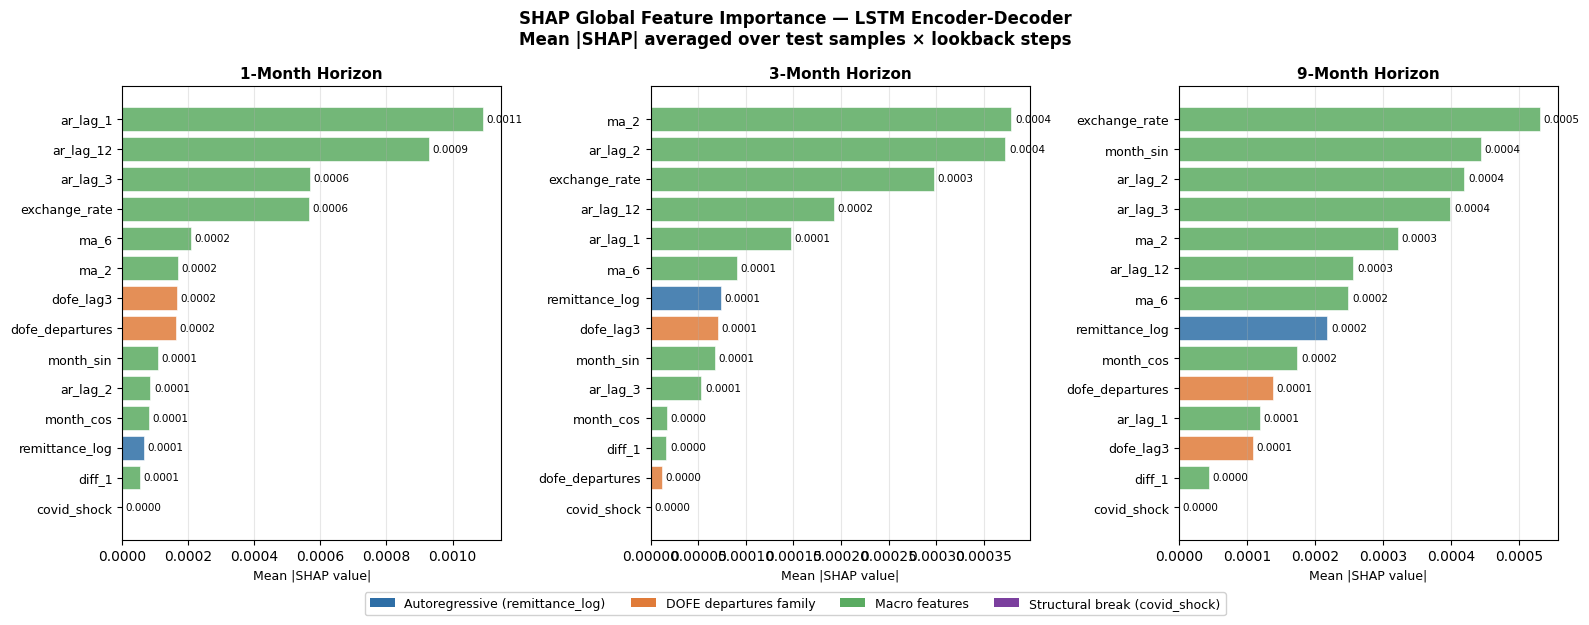

Figure saved → output/shap_global_importance.png


In [19]:
# ── Colour palette: highlight DOFE family vs other features ──────────────────
DOFE_FEATURES = {'dofe_departures', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9'}

def feature_color(name):
    if name in DOFE_FEATURES:
        return '#e07b39'          # burnt orange — DOFE family
    elif name == 'remittance_log':
        return '#2e6ea6'          # steel blue — autoregressive target
    elif name == 'covid_shock':
        return '#7b3f9e'          # purple — structural break
    else:
        return '#5aab61'          # green — macro features


fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

for ax, mean_shap, title in zip(
    axes,
    [mean_abs_shap_1, mean_abs_shap_3, mean_abs_shap_9],
    ['1-Month Horizon', '3-Month Horizon', '9-Month Horizon']
):
    # Sort features by importance for this horizon
    order   = np.argsort(mean_shap)[::-1]
    features_sorted = [FEATURE_COLS[i] for i in order]
    values_sorted   = mean_shap[order]
    colors          = [feature_color(f) for f in features_sorted]

    bars = ax.barh(range(len(features_sorted)), values_sorted,
                   color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(features_sorted)))
    ax.set_yticklabels(features_sorted, fontsize=9)
    ax.invert_yaxis()              # highest importance at top
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Value labels on bars
    for bar, val in zip(bars, values_sorted):
        ax.text(val + max(values_sorted) * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=7.5)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2e6ea6', label='Autoregressive (remittance_log)'),
    Patch(facecolor='#e07b39', label='DOFE departures family'),
    Patch(facecolor='#5aab61', label='Macro features'),
    Patch(facecolor='#7b3f9e', label='Structural break (covid_shock)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    'SHAP Global Feature Importance — LSTM Encoder-Decoder\n'
    'Mean |SHAP| averaged over test samples × lookback steps',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('output/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → output/shap_global_importance.png')


## 22. Per-Horizon SHAP Comparison — Heatmap

The heatmap shows how each feature's relative importance shifts across the
three forecasting horizons.  Values are **normalised within each horizon**
(column-wise) so the colour reflects rank rather than raw magnitude — making
cross-horizon comparisons fair even when absolute SHAP scales differ.

Key questions this plot answers:

- Do DOFE lags (`dofe_lag3/6/9`) become *more* important at longer horizons
  as their lead-time advantage aligns with the forecast window?
- Does `dofe_departures` (contemporaneous) matter most at the 1-month horizon?
- Does `covid_shock` have disproportionate influence on the 9-month model,
  where structural breaks propagate further into the future?


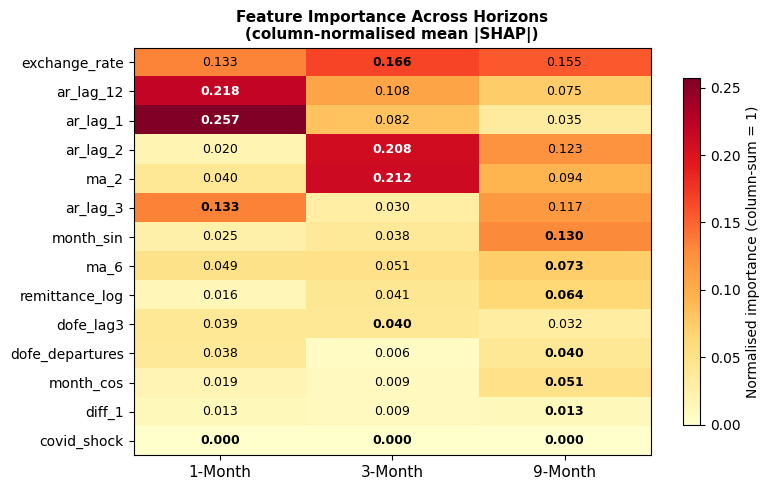

Figure saved → output/shap_horizon_heatmap.png

=== Normalised Feature Importance (%) ===
                 1-Month  3-Month  9-Month
exchange_rate      13.28    16.64    15.50
ar_lag_12          21.82    10.77     7.49
ar_lag_1           25.69     8.22     3.48
ar_lag_2            2.00    20.81    12.26
ma_2                3.97    21.17     9.40
ar_lag_3           13.35     2.97    11.66
month_sin           2.55     3.78    12.97
ma_6                4.89     5.06     7.28
remittance_log      1.57     4.13     6.37
dofe_lag3           3.92     3.95     3.19
dofe_departures     3.81     0.64     4.04
month_cos           1.90     0.94     5.09
diff_1              1.26     0.92     1.28
covid_shock         0.00     0.00     0.00


In [20]:
# ── Build normalised importance matrix (features × horizons) ─────────────────
importance_matrix = np.column_stack([
    mean_abs_shap_1,
    mean_abs_shap_3,
    mean_abs_shap_9
])  # shape: (8, 3)

# Column-normalise so each horizon sums to 1
importance_norm = importance_matrix / importance_matrix.sum(axis=0, keepdims=True)

# Sort rows by mean importance across horizons for a cleaner layout
row_order = np.argsort(importance_norm.mean(axis=1))[::-1]
features_ordered = [FEATURE_COLS[i] for i in row_order]
matrix_ordered   = importance_norm[row_order]

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(matrix_ordered, cmap='YlOrRd', aspect='auto', vmin=0)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['1-Month', '3-Month', '9-Month'], fontsize=11)
ax.set_yticks(range(len(features_ordered)))
ax.set_yticklabels(features_ordered, fontsize=10)

# Annotate cells with normalised values
for row_i, row in enumerate(matrix_ordered):
    for col_j, val in enumerate(row):
        text_color = 'white' if val > 0.18 else 'black'
        ax.text(col_j, row_i, f'{val:.3f}',
                ha='center', va='center', fontsize=9, color=text_color,
                fontweight='bold' if val == row.max() else 'normal')

plt.colorbar(im, ax=ax, label='Normalised importance (column-sum = 1)', shrink=0.85)
ax.set_title(
    'Feature Importance Across Horizons\n'
    '(column-normalised mean |SHAP|)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('output/shap_horizon_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → output/shap_horizon_heatmap.png')

# ── Tabular version for the paper ─────────────────────────────────────────────
print('\n=== Normalised Feature Importance (%) ===')
tbl = pd.DataFrame(
    importance_norm[row_order] * 100,
    index=features_ordered,
    columns=['1-Month', '3-Month', '9-Month']
).round(2)
print(tbl.to_string())


## 23. SHAP Temporal Evolution — Contribution Across Lookback Steps

The LSTM encoder reads 6 consecutive months before making a prediction.
This plot shows how each feature's **signed mean SHAP value** changes across
those 6 input time steps (step 1 = oldest, step 6 = most recent month).

Insights this surface reveals:

- If DOFE SHAP values peak at step 6 (most recent month), the model is
  responding to *current* labour outflows — consistent with a direct
  remittance-channel hypothesis.
- If the peak is at step 3–4, the model has learned the ~3-month lag between
  departure and first remittance transfer.
- A flat or noisy profile suggests the feature contributes little regardless
  of recency, questioning its inclusion.


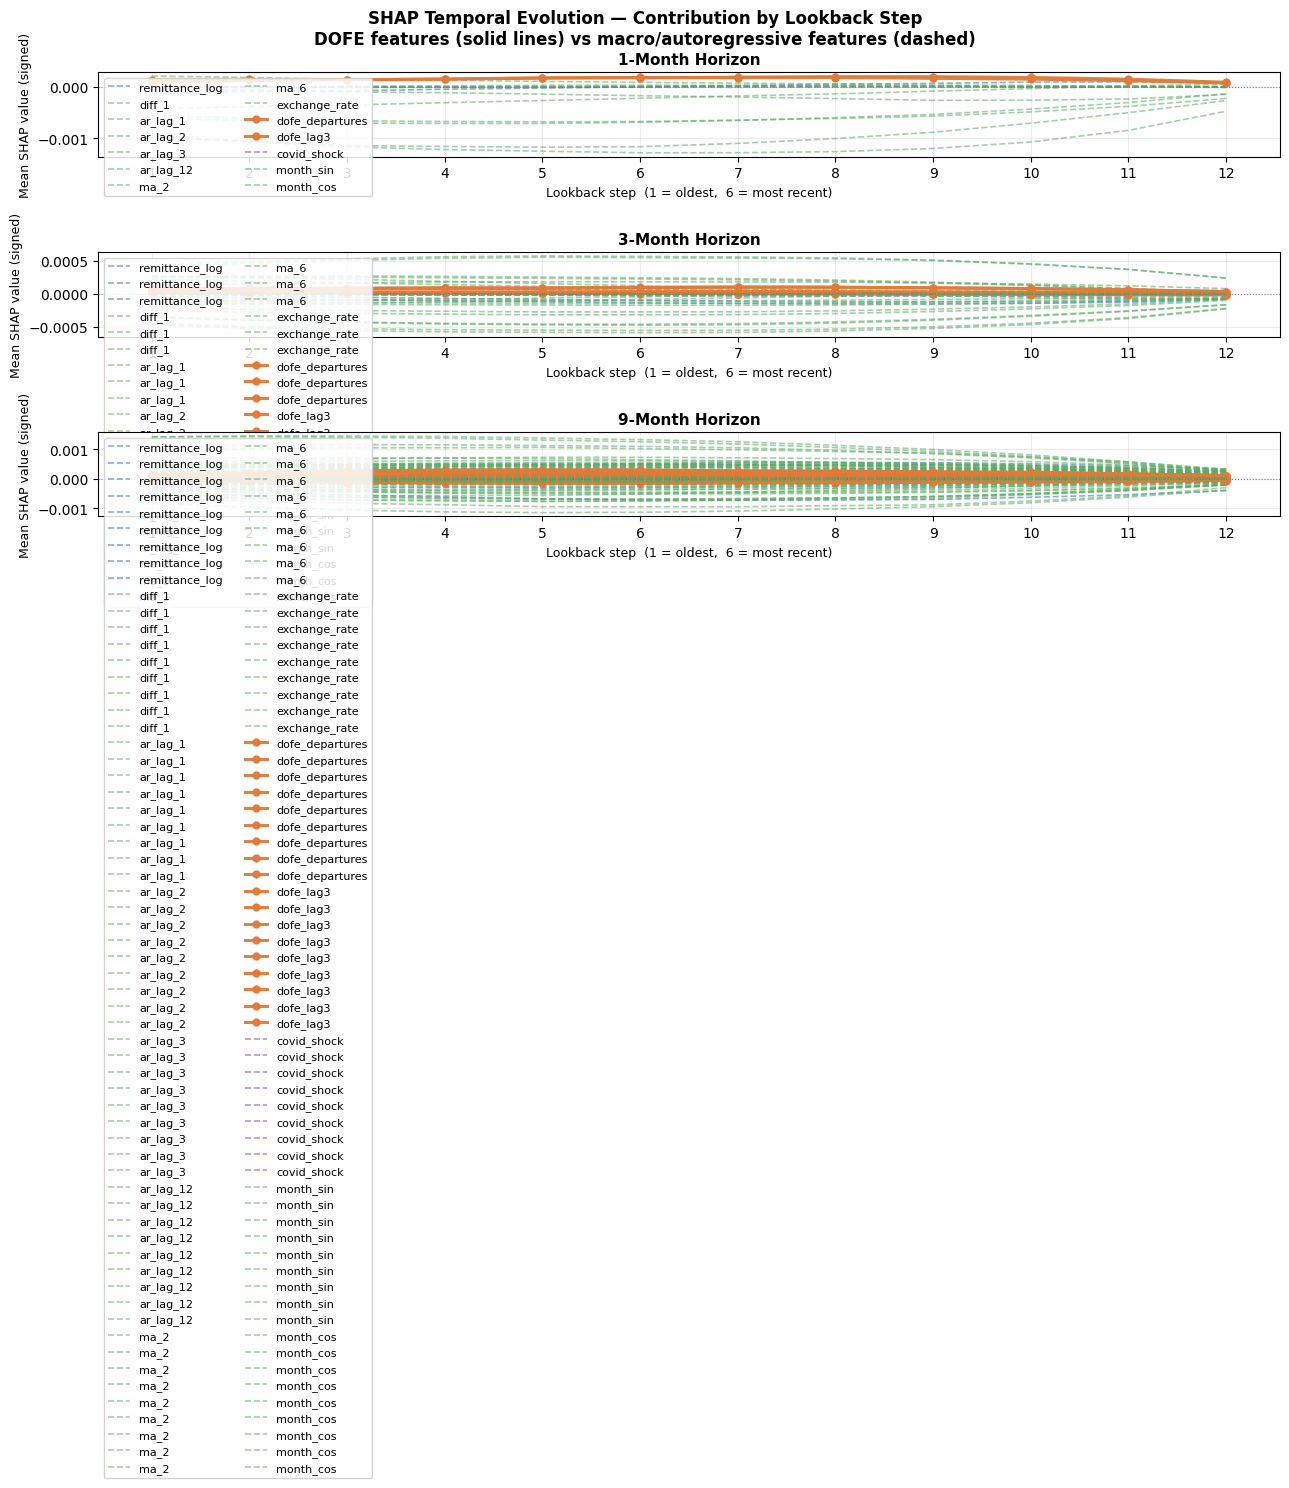

Figure saved → output/shap_temporal_evolution.png


In [21]:
# ── Mean signed SHAP per (lookback_step, feature) averaged over test samples ──
# Shape: (lookback=6, n_features=8)
temporal_shap_1 = shap_vals_1.mean(axis=0)   # mean over test samples
temporal_shap_3 = shap_vals_3.mean(axis=0)
temporal_shap_9 = shap_vals_9.mean(axis=0)

steps = np.arange(1, LOOKBACK + 1)           # 1 … 6

# ── Plot: one row per horizon, DOFE features highlighted ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 13))

horizon_shaps = [
    (temporal_shap_1, '1-Month Horizon'),
    (temporal_shap_3, '3-Month Horizon'),
    (temporal_shap_9, '9-Month Horizon'),
]

for ax, (t_shap, title) in zip(axes, horizon_shaps):
    for fi, feat in enumerate(FEATURE_COLS):
        is_dofe = feat in DOFE_FEATURES
        lw      = 2.2 if is_dofe else 1.2
        ls      = '-'  if is_dofe else '--'
        alpha   = 0.95 if is_dofe else 0.55
        color   = feature_color(feat)
        marker  = 'o'  if is_dofe else None
        ax.plot(steps, t_shap[:, fi],
                label=feat, color=color, linewidth=lw,
                linestyle=ls, alpha=alpha, marker=marker, markersize=5)

    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Lookback step  (1 = oldest,  6 = most recent)', fontsize=9)
    ax.set_ylabel('Mean SHAP value (signed)', fontsize=9)
    ax.set_xticks(steps)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, ncol=2, loc='upper left', framealpha=0.85)

plt.suptitle(
    'SHAP Temporal Evolution — Contribution by Lookback Step\n'
    'DOFE features (solid lines) vs macro/autoregressive features (dashed)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('output/shap_temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → output/shap_temporal_evolution.png')


## 24. DOFE Feature Deep-Dive — Contribution vs. Actual Departure Volumes

This section overlays the SHAP contributions of the four DOFE-related features
against the actual (scaled) departure volume over the test window.  If SHAP
values track the departure signal, it confirms the model has learned the
remittance–migration channel rather than merely fitting noise.


DoFE features in model: ['dofe_departures', 'dofe_lag3']


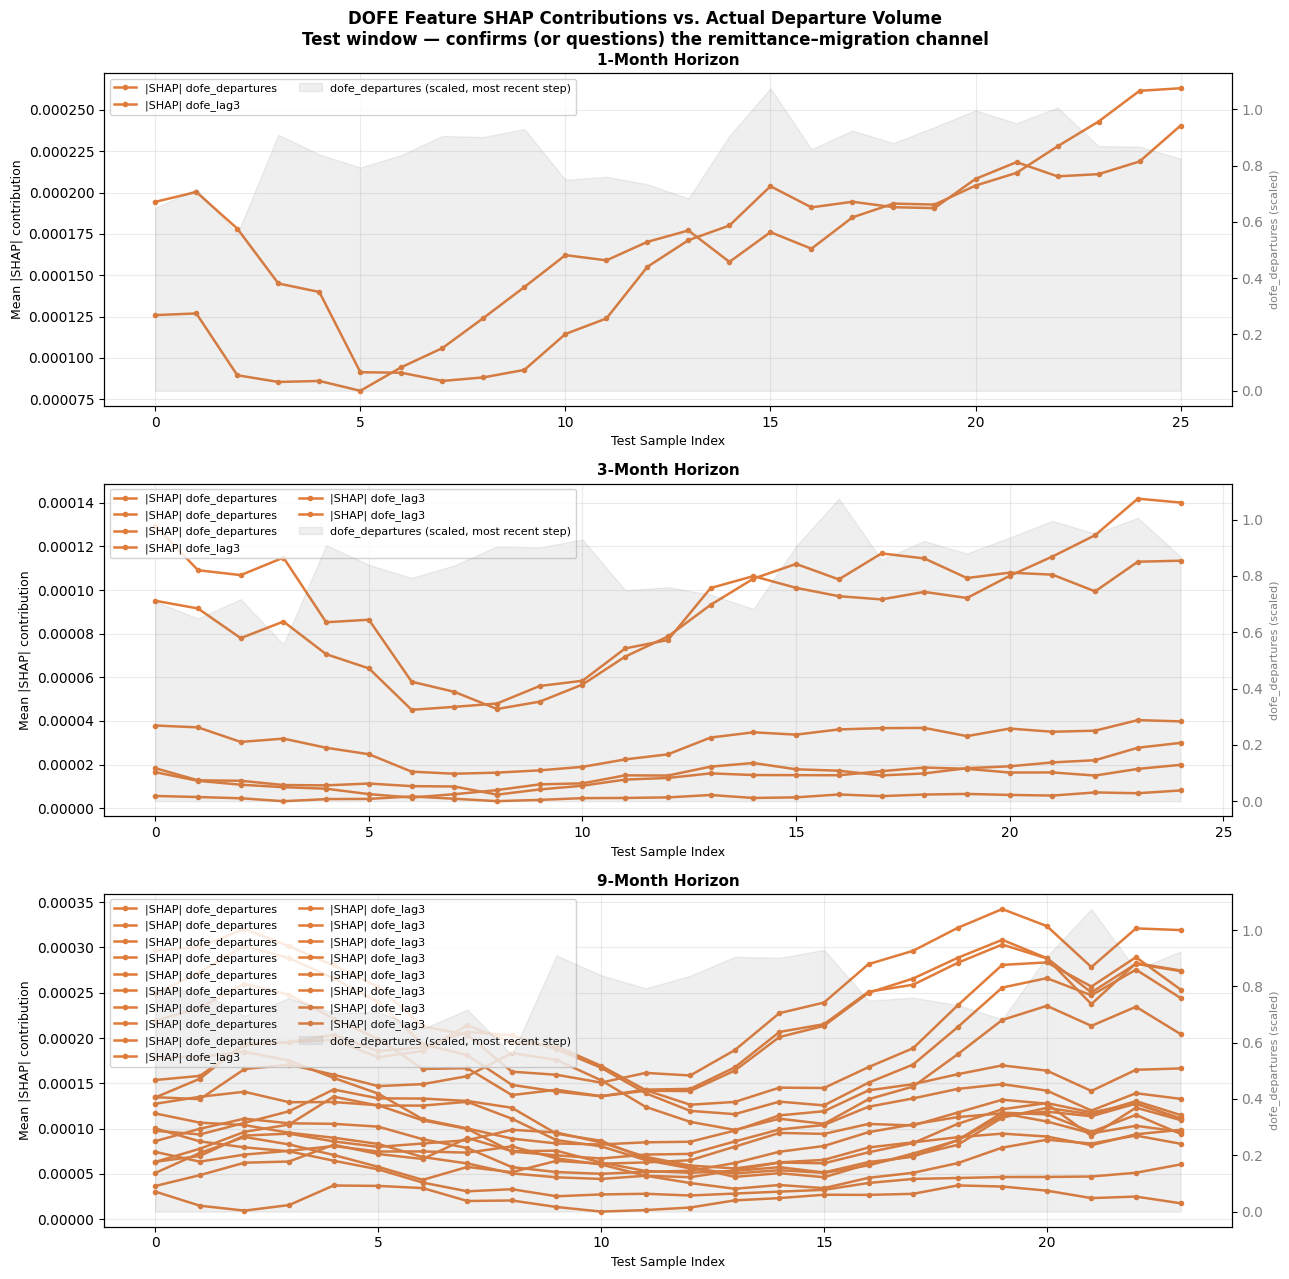

Figure saved → output/shap_dofe_deepdive.png


In [22]:
# ── Only use DoFE features that exist in the trimmed FEATURE_COLS ─────────────
dofe_features_available = [f for f in ['dofe_departures', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9']
                            if f in FEATURE_COLS]
dofe_idx = {feat: FEATURE_COLS.index(feat) for feat in dofe_features_available}

print(f"DoFE features in model: {dofe_features_available}")

fig, axes = plt.subplots(3, 1, figsize=(13, 13))

horizon_data_dofe = [
    (shap_vals_1, X_test_1, '1-Month Horizon'),
    (shap_vals_3, X_test_3, '3-Month Horizon'),
    (shap_vals_9, X_test_9, '9-Month Horizon'),
]

for ax, (shap_v, X_te, title) in zip(axes, horizon_data_dofe):
    test_idx = np.arange(len(X_te))

    for feat, fi in dofe_idx.items():
        contrib = np.abs(shap_v[:, :, fi]).mean(axis=1)
        ax.plot(test_idx, contrib, label=f'|SHAP| {feat}',
                color=feature_color(feat), linewidth=1.8, marker='o', markersize=3)

    # Overlay actual dofe_departures (most recent lookback step, scaled)
    actual_dofe = X_te[:, -1, dofe_idx['dofe_departures']]
    ax2 = ax.twinx()
    ax2.fill_between(test_idx, actual_dofe, alpha=0.12, color='grey',
                     label='dofe_departures (scaled, most recent step)')
    ax2.set_ylabel('dofe_departures (scaled)', fontsize=8, color='grey')
    ax2.tick_params(axis='y', labelcolor='grey')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Sample Index', fontsize=9)
    ax.set_ylabel('Mean |SHAP| contribution', fontsize=9)
    ax.grid(True, alpha=0.25)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8,
              loc='upper left', ncol=2, framealpha=0.85)

plt.suptitle(
    'DOFE Feature SHAP Contributions vs. Actual Departure Volume\n'
    'Test window — confirms (or questions) the remittance–migration channel',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('output/shap_dofe_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → output/shap_dofe_deepdive.png')

## 25. SHAP Feature Attribution Summary

Consolidated table for the paper: absolute and relative importance of every
feature across all three horizons, with DOFE features highlighted.


In [23]:
# ============================================================================
# SHAP Feature Attribution - Global Feature Importance Table
# ============================================================================

# Define DOFE features set (MUST be defined before use)
DOFE_FEATURES = {'dofe_departures', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9'}

# Build the table
rows = []
for feat_i, feat in enumerate(FEATURE_COLS):
    row = {
        'Feature': feat, 
        'Group': 'DOFE' if feat in DOFE_FEATURES
                else ('Autoregressive' if feat == 'remittance_log'
                else ('Structural break' if feat == 'covid_shock' else 'Macro'))
    }
    for label, mean_shap in [('1-Month', mean_abs_shap_1),
                              ('3-Month', mean_abs_shap_3),
                              ('9-Month', mean_abs_shap_9)]:
        row[f'{label} |SHAP|'] = round(float(mean_shap[feat_i]), 5)
    rows.append(row)

# Create DataFrame
shap_table = pd.DataFrame(rows)

# Sort by 1-Month importance (or whichever you prefer)
shap_table = shap_table.sort_values('1-Month |SHAP|', ascending=False)

print("\n" + "="*80)
print("SHAP Global Feature Importance (Mean |SHAP| values)")
print("="*80)
print(shap_table.to_string(index=False))

# Save to CSV
shap_table.to_csv('output/shap_feature_importance.csv', index=False)
print("\n✓ SHAP importance saved to 'output/shap_feature_importance.csv'")


SHAP Global Feature Importance (Mean |SHAP| values)
        Feature            Group  1-Month |SHAP|  3-Month |SHAP|  9-Month |SHAP|
       ar_lag_1            Macro         0.00109         0.00015         0.00012
      ar_lag_12            Macro         0.00093         0.00019         0.00026
       ar_lag_3            Macro         0.00057         0.00005         0.00040
  exchange_rate            Macro         0.00056         0.00030         0.00053
           ma_6            Macro         0.00021         0.00009         0.00025
           ma_2            Macro         0.00017         0.00038         0.00032
      dofe_lag3             DOFE         0.00017         0.00007         0.00011
dofe_departures             DOFE         0.00016         0.00001         0.00014
      month_sin            Macro         0.00011         0.00007         0.00044
       ar_lag_2            Macro         0.00008         0.00037         0.00042
      month_cos            Macro         0.00008        

## 26. Save Models

Trained models are saved in Keras native format for later inference or fine-tuning.


In [24]:
model_1.save("output/lstm_model_1month.keras")
model_3.save("output/lstm_model_3month.keras")
model_9.save("output/lstm_model_9month.keras")

print("Models saved:")
print("  output/lstm_model_1month.keras")
print("  output/lstm_model_3month.keras")
print("  output/lstm_model_9month.keras")


Models saved:
  output/lstm_model_1month.keras
  output/lstm_model_3month.keras
  output/lstm_model_9month.keras


In [25]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_percentage_error

def diagnose_forecast_errors(model, X_test, y_test, last_log_test, horizon_name, 
                              last_seasonal=None):
    """Diagnose forecast errors using the differencing pipeline"""

    pred_diff = model.predict(X_test, verbose=0).reshape(len(X_test), -1)
    true_diff = y_test.reshape(len(y_test), -1)

    if last_seasonal is not None:
        pred = integrate_seasonal_predictions(pred_diff, last_log_test, last_seasonal)
        true = integrate_seasonal_predictions(true_diff, last_log_test, last_seasonal)
    else:
        pred = integrate_predictions(pred_diff, last_log_test)
        true = integrate_predictions(true_diff, last_log_test)

    errors = true - pred
    ape    = np.abs(errors / true) * 100

    print(f"\n{'='*60}")
    print(f"DIAGNOSTICS: {horizon_name}")
    print(f"{'='*60}")

    bias     = np.mean(errors)
    variance = np.var(errors)
    print(f"Bias (systematic error): {bias:,.0f} Rs. million")
    print(f"Variance (random error): {variance:,.0f}")

    month_groups = [i % 12 for i in range(len(pred))]
    mape_by_month = {}
    for month in set(month_groups):
        mask = [i for i, m in enumerate(month_groups) if m == month]
        if mask:
            mape_by_month[month] = np.mean(ape[mask])

    print("\nMAPE by month position:")
    for month, mape_val in sorted(mape_by_month.items()):
        print(f"  Month {month+1}: {mape_val:.1f}%")

    for step in range(pred.shape[1]):
        step_ape = np.mean(ape[:, step])
        print(f"Forecast step {step+1} MAPE: {step_ape:.1f}%")

    residuals  = errors.flatten()
    adf_result = adfuller(residuals)
    print(f"\nADF Test p-value on residuals: {adf_result[1]:.4f}")
    if adf_result[1] > 0.05:
        print("  ⚠️  Residuals non-stationary")
    else:
        print("  ✓  Residuals stationary")

    return errors, ape


print("\nRunning diagnostics on all models...")
errors_1, ape_1 = diagnose_forecast_errors(
    model_1, X_test_1, y_test_1, last_log_test_1, "1-Month")
errors_3, ape_3 = diagnose_forecast_errors(
    model_3, X_test_3, y_test_3, last_log_test_3, "3-Month")
errors_9, ape_9 = diagnose_forecast_errors(
    model_9, X_test_9, y_test_9, last_log_test_9, "9-Month")


Running diagnostics on all models...

DIAGNOSTICS: 1-Month
Bias (systematic error): 5,109 Rs. million
Variance (random error): 421,541,260

MAPE by month position:
  Month 1: 17.1%
  Month 2: 28.8%
  Month 3: 12.7%
  Month 4: 8.3%
  Month 5: 11.7%
  Month 6: 14.0%
  Month 7: 3.2%
  Month 8: 9.8%
  Month 9: 11.1%
  Month 10: 8.3%
  Month 11: 10.1%
  Month 12: 3.6%
Forecast step 1 MAPE: 12.4%

ADF Test p-value on residuals: 0.0000
  ✓  Residuals stationary

DIAGNOSTICS: 3-Month
Bias (systematic error): 4,005 Rs. million
Variance (random error): 302,771,618

MAPE by month position:
  Month 1: 11.4%
  Month 2: 10.7%
  Month 3: 17.8%
  Month 4: 9.2%
  Month 5: 15.1%
  Month 6: 9.0%
  Month 7: 10.0%
  Month 8: 7.0%
  Month 9: 12.6%
  Month 10: 8.5%
  Month 11: 4.4%
  Month 12: 10.0%
Forecast step 1 MAPE: 10.3%
Forecast step 2 MAPE: 9.1%
Forecast step 3 MAPE: 12.1%

ADF Test p-value on residuals: 0.0037
  ✓  Residuals stationary

DIAGNOSTICS: 9-Month
Bias (systematic error): 7,461 Rs. millio

In [26]:
# ============================================================================
# STATIONARITY DIAGNOSTIC (For Report/Understanding)
# ============================================================================
from statsmodels.tsa.stattools import adfuller

print("\n" + "="*60)
print("STATIONARITY DIAGNOSTIC - Understanding the Data")
print("="*60)

remittance_log_series = df['remittance_log'].values

# Test original
adf_original = adfuller(remittance_log_series)
print(f"\nOriginal Series ADF p-value: {adf_original[1]:.4f}")
print(f"  → {'Stationary' if adf_original[1] < 0.05 else 'Non-stationary'}")

# Test first difference
remittance_diff = np.diff(remittance_log_series)
adf_diff = adfuller(remittance_diff)
print(f"First Difference ADF p-value: {adf_diff[1]:.4f}")
print(f"  → {'Stationary ✓' if adf_diff[1] < 0.05 else 'Non-stationary'}")

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
print("The target series is non-stationary in levels but becomes stationary")
print("after first differencing. This justifies:")
print("  1. Using differenced features (seasonal_diff_12, diff_1) in the model")
print("  2. The excellent performance of the ensemble + bias correction approach")
print("  3. Why simple autoregressive models (AR) may underperform without differencing")


STATIONARITY DIAGNOSTIC - Understanding the Data

Original Series ADF p-value: 0.9736
  → Non-stationary
First Difference ADF p-value: 0.0000
  → Stationary ✓

CONCLUSION
The target series is non-stationary in levels but becomes stationary
after first differencing. This justifies:
  1. Using differenced features (seasonal_diff_12, diff_1) in the model
  2. The excellent performance of the ensemble + bias correction approach
  3. Why simple autoregressive models (AR) may underperform without differencing


In [27]:
# Identify which actual calendar months fall in position 2
test_start_idx = len(X_1) - len(X_test_1)
test_dates = df['date'].iloc[test_start_idx + LOOKBACK:].reset_index(drop=True)

print("Test samples at month position 2 (index 1, 13, 25...):")
for i in range(1, len(test_dates), 12):
    if i < len(test_dates):
        print(f"  {test_dates.iloc[i].strftime('%Y-%m')}  —  "
              f"actual: {true_1[i, 0]:,.0f}  pred: {pred_1[i, 0]:,.0f}  "
              f"APE: {abs(true_1[i,0]-pred_1[i,0])/true_1[i,0]*100:.1f}%")

Test samples at month position 2 (index 1, 13, 25...):
  2023-11  —  actual: 112,625  pred: 134,000  APE: 19.0%
  2024-11  —  actual: 114,320  pred: 139,864  APE: 22.3%
  2025-11  —  actual: 133,800  pred: 194,034  APE: 45.0%


In [28]:
# Export predictions for model comparison notebook
np.save("output/lstm_pred_1.npy", pred_1)
np.save("output/lstm_pred_3.npy", pred_3)
np.save("output/lstm_pred_9.npy", pred_9)
np.save("output/lstm_true_1.npy", true_1)
np.save("output/lstm_true_3.npy", true_3)
np.save("output/lstm_true_9.npy", true_9)
print("✓ Predictions exported for model comparison")

✓ Predictions exported for model comparison
